<a href="https://colab.research.google.com/github/jdnogues/DIO/blob/main/Desafio_DIO_Detec%C3%A7%C3%A3o_e_Reconhecimento_Facial_no_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Detecção e Reconhecimento Facial no Colab**

**Passo 1: Instalação das Bibliotecas**

Vamos começar instalando os pacotes necessários. A facenet-pytorch já vem com o detector MTCNN e o reconhecedor FaceNet.

In [2]:
# Instala um conjunto específico e estável de bibliotecas que estão disponíveis no repositório do Colab.
print("Instalando um ambiente de bibliotecas controlado e compatível...")
!pip install torch==2.0.1 torchvision==0.15.2 torchaudio==2.0.2 numpy==1.23.5 Pillow==9.5.0 facenet-pytorch -q

print("\nAmbiente controlado instalado com sucesso!")

Instalando um ambiente de bibliotecas controlado e compatível...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 MB 10.7 MB/

# Após executar o passo 1, é **OBRIGATÓRIO REINICAR O AMBIENTE DE EXECUÇÃO**

Para isso, acesse no menu superior o item Ambiente de Execução e clique em Reiniciar Sessão (CTRL + M .)

**Teste de Importação**
Testa se as bibliotecas foram importadas corretamente, sem conflitos por versionamento

In [1]:
# Célula de teste de importação
try:
    from facenet_pytorch import MTCNN, InceptionResnetV1, prewhiten
    import torch
    from PIL import Image
    print("✅ SUCESSO! Ambiente estável e bibliotecas importadas corretamente.")
except ImportError as e:
    print(f"❌ FALHA: O erro de importação ainda ocorre. Erro: {e}")
except Exception as e:
    print(f"❌ FALHA: Ocorreu um erro inesperado. Erro: {e}")

✅ SUCESSO! Ambiente estável e bibliotecas importadas corretamente.


#**Parte 1: Detecção Facial (Encontrando os Rostos)**

Nesta primeira parte, vamos apenas usar o detector para encontrar as faces em uma imagem de teste.

**Passo 2: Carregar o Modelo de Detecção (MTCNN)**

A biblioteca facenet-pytorch nos dá acesso direto a um detector facial de alta precisão chamado MTCNN.

In [2]:
from facenet_pytorch import MTCNN
import torch
from PIL import Image, ImageDraw
import requests
from io import BytesIO

# Verifica se uma GPU está disponível e a seleciona, caso contrário usa a CPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Rodando na {device}')

# Cria o detector MTCNN
# image_size: tamanho da imagem após o recorte da face
# margin: adiciona uma margem ao redor da face detectada para garantir que todo o rosto seja capturado
mtcnn = MTCNN(image_size=160, margin=10, device=device)

Rodando na cpu


**Passo 3: Testar o Detector em uma Imagem**

Vamos baixar uma imagem e ver o detector em ação.

Baixando a imagem de teste do link: https://img.freepik.com/fotos-gratis/amigos-idosos-jogando-petanca_23-2149443876.jpg?semt=ais_hybrid&w=740&q=80
Imagem baixada e aberta com sucesso.
Detectadas 3 faces!


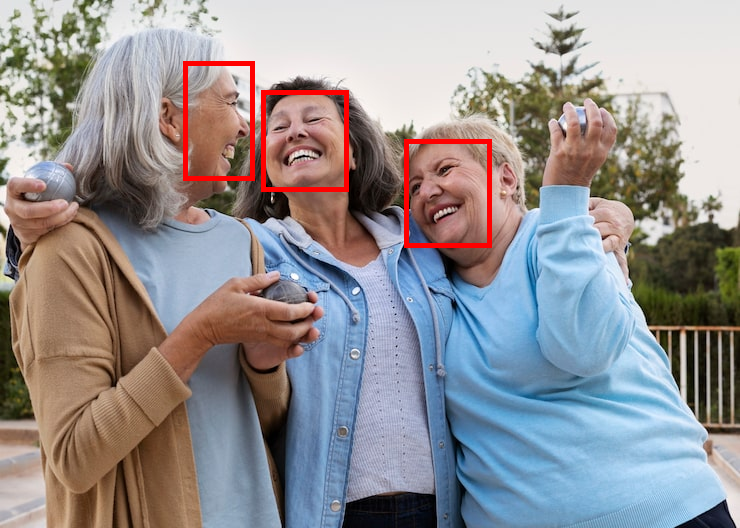

In [30]:
from PIL import Image, ImageDraw, UnidentifiedImageError
import requests
from io import BytesIO

url = 'https://img.freepik.com/fotos-gratis/amigos-idosos-jogando-petanca_23-2149443876.jpg?semt=ais_hybrid&w=740&q=80'

print(f"Baixando a imagem de teste do link: {url}")
response = requests.get(url)

try:
    # Tenta abrir a imagem a partir do conteúdo baixado
    img = Image.open(BytesIO(response.content))
    print("Imagem baixada e aberta com sucesso.")

    # Detecta as faces na imagem
    # O detector retorna as caixas delimitadoras (bounding boxes) e a probabilidade de ser uma face
    boxes, probs = mtcnn.detect(img)

    # Prepara para desenhar na imagem
    img_draw = img.copy()
    draw = ImageDraw.Draw(img_draw)

    # Desenha as caixas na imagem se alguma face for encontrada
    if boxes is not None:
        print(f"Detectadas {len(boxes)} faces!")
        for box in boxes:
            draw.rectangle(box.tolist(), outline='red', width=5)
    else:
        print("Nenhuma face detectada na imagem.")

    # Exibe a imagem com as faces detectadas
    display(img_draw)

except UnidentifiedImageError:
    print("\nERRO: Falha ao identificar a imagem. O link pode estar quebrado ou o conteúdo baixado não é uma imagem válida.")
except Exception as e:
    print(f"\nOcorreu um erro inesperado: {e}")

# **Parte 2: Reconhecimento Facial (Identificando as Pessoas)**

Agora, vamos à parte do reconhecimento. O fluxo de trabalho é:
Criar uma pequena "base de dados" de pessoas conhecidas.
Gerar uma "impressão digital facial" (embedding) para cada pessoa.
Comparar as faces de uma nova imagem com nossa base de dados.

**Passo 4: Preparar a Base de Dados de Pessoas Conhecidas**

Vamos criar uma estrutura de pastas e baixar imagens de 3 pessoas para serem as nossas "identidades conhecidas".

In [14]:
import os
import requests
from io import BytesIO

# Estrutura de pastas para a nossa base de dados
os.makedirs('database/pele', exist_ok=True)
os.makedirs('database/marta', exist_ok=True)
os.makedirs('database/neymar', exist_ok=True)

# Baixando imagens de exemplo para cada pessoa
print("Baixando imagens para a base de dados...")

# URLs das imagens
urls = {
    'pele': [
        'https://s2-gq.glbimg.com/TrLY7B7DDsoZT0OIHxb0W-ElSxQ=/0x0:1536x949/924x0/smart/filters:strip_icc()/i.s3.glbimg.com/v1/AUTH_71a8fe14ac6d40bd993eb59f7203fe6f/internal_photos/bs/2022/c/g/gbcIcITfOAgRqerTpmIg/sem-titulo-1.jpg',
        'https://upload.wikimedia.org/wikipedia/commons/thumb/5/54/Pele_by_John_Mathew_Smith.jpg/250px-Pele_by_John_Mathew_Smith.jpg'
    ],
    'marta': [
        'https://blog.futfanatics.com.br/wp-content/uploads/2021/06/Marta-Destaque.png',
        'https://fdr.com.br/wp-content/uploads/2021/07/fd3ce297-1000.jpg'
    ],
    'neymar': [
        'https://upload.wikimedia.org/wikipedia/commons/8/83/Bra-Cos_%281%29_%28cropped%29.jpg',
        'https://library.sportingnews.com/styles/crop_style_16_9_desktop_webp/s3/2025-03/GettyImages-1447164827.jpg.webp?itok=NnskFZnr'
    ]
}

# Baixando as imagens
for person_name, image_urls in urls.items():
    person_folder = os.path.join('database', person_name)
    for i, url in enumerate(image_urls):
        filename = os.path.join(person_folder, f'{person_name}_{i+1}.jpg')
        try:
            print(f"Tentando baixar: {url} para {filename}")
            response = requests.get(url, stream=True)
            response.raise_for_status() # Levanta um erro para códigos de status ruins (4xx ou 5xx)
            with open(filename, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)
            print(f"Baixado com sucesso: {filename}")
        except requests.exceptions.RequestException as e:
            print(f"Erro ao baixar {url} para {filename}: {e}")
        except Exception as e:
            print(f"Ocorreu um erro inesperado ao baixar {url}: {e}")

print("\nVerificando arquivos baixados...")
for person_name in os.listdir('database'):
    person_folder = os.path.join('database', person_name)
    if os.path.isdir(person_folder):
        files_in_folder = os.listdir(person_folder)
        print(f"Pasta '{person_folder}': {len(files_in_folder)} arquivos encontrados.")
        # Opcional: listar os arquivos encontrados
        # for file in files_in_folder:
        #     print(f"  - {file}")


print("\nBase de dados de pessoas conhecidas criada (tentativa de download)!")

Baixando imagens para a base de dados...
Tentando baixar: https://s2-gq.glbimg.com/TrLY7B7DDsoZT0OIHxb0W-ElSxQ=/0x0:1536x949/924x0/smart/filters:strip_icc()/i.s3.glbimg.com/v1/AUTH_71a8fe14ac6d40bd993eb59f7203fe6f/internal_photos/bs/2022/c/g/gbcIcITfOAgRqerTpmIg/sem-titulo-1.jpg para database/pele/pele_1.jpg
Baixado com sucesso: database/pele/pele_1.jpg
Tentando baixar: https://upload.wikimedia.org/wikipedia/commons/thumb/5/54/Pele_by_John_Mathew_Smith.jpg/250px-Pele_by_John_Mathew_Smith.jpg para database/pele/pele_2.jpg
Baixado com sucesso: database/pele/pele_2.jpg
Tentando baixar: https://blog.futfanatics.com.br/wp-content/uploads/2021/06/Marta-Destaque.png para database/marta/marta_1.jpg
Baixado com sucesso: database/marta/marta_1.jpg
Tentando baixar: https://fdr.com.br/wp-content/uploads/2021/07/fd3ce297-1000.jpg para database/marta/marta_2.jpg
Baixado com sucesso: database/marta/marta_2.jpg
Tentando baixar: https://upload.wikimedia.org/wikipedia/commons/8/83/Bra-Cos_%281%29_%28cro

**Passo 5: Carregar o Modelo de Reconhecimento e Gerar "Embeddings"**

Vamos carregar o modelo FaceNet, que transforma uma imagem de rosto em um vetor numérico (embedding).

In [15]:
from facenet_pytorch import InceptionResnetV1

# Carrega o modelo FaceNet pré-treinado
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

# Dicionário para armazenar os embeddings das pessoas conhecidas
known_embeddings = {}

# Itera sobre cada pessoa na base de dados
for person_name in os.listdir('database'):
    person_folder = os.path.join('database', person_name)
    if os.path.isdir(person_folder):
        embeddings = []
        for img_name in os.listdir(person_folder):
            img_path = os.path.join(person_folder, img_name)
            img = Image.open(img_path).convert('RGB')

            # Detecta e recorta a face da imagem
            face = mtcnn(img)
            if face is not None:
                # Gera o embedding e o armazena
                face = face.to(device)
                embedding = resnet(face.unsqueeze(0)).detach().cpu()
                embeddings.append(embedding)

        # Calcula o embedding médio para a pessoa (mais robusto)
        if embeddings:
            known_embeddings[person_name] = torch.cat(embeddings).mean(dim=0, keepdim=True)
            print(f"Embedding gerado para: {person_name}")

Embedding gerado para: pele
Embedding gerado para: neymar
Embedding gerado para: marta


**Passo 6: Testar o Sistema de Reconhecimento Completo**

Agora, vamos usar uma nova imagem, detectar as faces e compará-las com nossa base de dados.

Baixando e abrindo a imagem de teste...
Imagem de teste pronta.
Detectando faces...


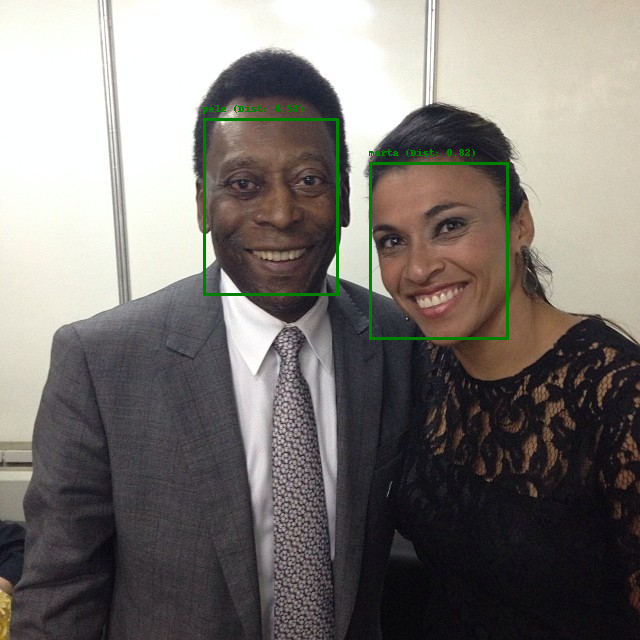

In [27]:
import torchvision.transforms as transforms
from facenet_pytorch import prewhiten # Import prewhiten directly from facenet_pytorch
import torch.nn.functional as F
import requests
from io import BytesIO
from PIL import Image, ImageDraw

# URL da imagem de teste
url_test = 'https://s2.glbimg.com/ULponuZ85Z30E80el5zOA35-AjA=/e.glbimg.com/og/ed/f/original/2021/07/22/martavsilva10_.jpg'

try:
    print("Baixando e abrindo a imagem de teste...")
    response_test = requests.get(url_test)
    img_test = Image.open(BytesIO(response_test.content)).convert('RGB')
    print("Imagem de teste pronta.")

    # --- PIPELINE MANUAL ---

    # 1. DETECÇÃO: Usamos o mtcnn apenas para encontrar as caixas delimitadoras.
    print("Detectando faces...")
    boxes, _ = mtcnn.detect(img_test)

    if boxes is not None:
        img_draw_test = img_test.copy()
        draw_test = ImageDraw.Draw(img_draw_test)

        # 2. ITERAÇÃO: Passamos por cada face encontrada.
        for box in boxes:
            # 3. RECORTE E REDIMENSIONAMENTO: Recortamos a face e garantimos o tamanho 160x160.
            face_pil = img_test.crop(box).resize((160, 160), Image.BILINEAR)

            # 4. CONVERSÃO PARA TENSOR: Convertemos a face para o formato tensor.
            transform = transforms.ToTensor()
            face_tensor = transform(face_pil)

            # 5. NORMALIZAÇÃO: Normalizamos o tensor (etapa crucial que era feita internamente).
            face_tensor = prewhiten(face_tensor)

            # 6. RECONHECIMENTO: Geramos o embedding com o modelo resnet.
            face_tensor = face_tensor.to(device)
            embedding_test = resnet(face_tensor.unsqueeze(0)).detach().cpu()

            # 7. COMPARAÇÃO: Comparamos com nossa base de dados (lógica inalterada).
            min_dist = float('inf')
            recognized_name = "Desconhecido"

            for name, known_emb in known_embeddings.items():
                dist = (embedding_test - known_emb).norm().item()
                if dist < min_dist:
                    min_dist = dist
                    recognized_name = name

            # Ajuste o threshold conforme necessário
            threshold = 1.0  # Aumentando o threshold um pouco para permitir maior variação
            if min_dist > threshold:
                recognized_name = "Desconhecido"

            # 8. EXIBIÇÃO: Desenhamos o resultado na imagem.
            box_list = box.tolist()
            draw_test.rectangle(box_list, outline='green', width=3)
            draw_test.text((box_list[0], box_list[1] - 15), f"{recognized_name} (Dist: {min_dist:.2f})", fill='green')

        display(img_draw_test)
    else:
        print("Nenhuma face detectada na imagem de teste.")

except Exception as e:
    print(f"\nOcorreu um erro inesperado: {e}")